In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [12]:
# FUNCTION: GET PREDICTIONS

def get_predictions(model, loader, device):
    model.eval()

    actual, predicted = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            preds = model(X_batch)

            actual.extend(y_batch.cpu().numpy())
            predicted.extend(preds.cpu().numpy())

    return np.array(actual).flatten(), np.array(predicted).flatten()

In [13]:
# INVERSE TRANSFORM

def inverse_transform(values, scaler, cols_to_scale):
    
    dummy = np.zeros((len(values), len(cols_to_scale)))
    target_idx = cols_to_scale.index("units_sold")

    dummy[:, target_idx] = values

    return scaler.inverse_transform(dummy)[:, target_idx]


In [14]:
# MAIN VISUALIZATION

def plot_evaluation(lstm_model, mlp_model, lstm_loader, mlp_loader, device, scaler, cols_to_scale):

    
    # predictions
    
    y_true_lstm, y_pred_lstm = get_predictions(lstm_model, lstm_loader, device)
    y_true_mlp, y_pred_mlp = get_predictions(mlp_model, mlp_loader, device)

    # inverse scale
   
    actual = inverse_transform(y_true_lstm, scaler, cols_to_scale)
    lstm_pred = inverse_transform(y_pred_lstm, scaler, cols_to_scale)
    mlp_pred = inverse_transform(y_pred_mlp, scaler, cols_to_scale)

    
    # 1. ACTUAL vs PREDICTED (LSTM)
    
    plt.figure(figsize=(12, 5))
    plt.plot(actual[:100], label="Actual", linewidth=2)
    plt.plot(lstm_pred[:100], label="LSTM Prediction", linestyle="dashed")

    plt.title("LSTM: Actual vs Predicted Demand")
    plt.xlabel("Samples")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.show()


    # 2. ACTUAL vs PREDICTED (MLP)
    
    plt.figure(figsize=(12, 5))
    plt.plot(actual[:100], label="Actual", linewidth=2)
    plt.plot(mlp_pred[:100], label="MLP Prediction", linestyle="dashed")

    plt.title("MLP: Actual vs Predicted Demand")
    plt.xlabel("Samples")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.show()


    
    # 3. COMPARISON GRAPH (IMPORTANT FOR EVALUATION)
    
    plt.figure(figsize=(12, 6))

    plt.plot(actual[:100], label="Actual", linewidth=2)
    plt.plot(lstm_pred[:100], label="LSTM", linestyle="dashed")
    plt.plot(mlp_pred[:100], label="MLP", linestyle="dotted")

    plt.title("Model Comparison: LSTM vs MLP vs Actual")
    plt.xlabel("Samples")
    plt.ylabel("Units Sold")
    plt.legend()

    plt.show()

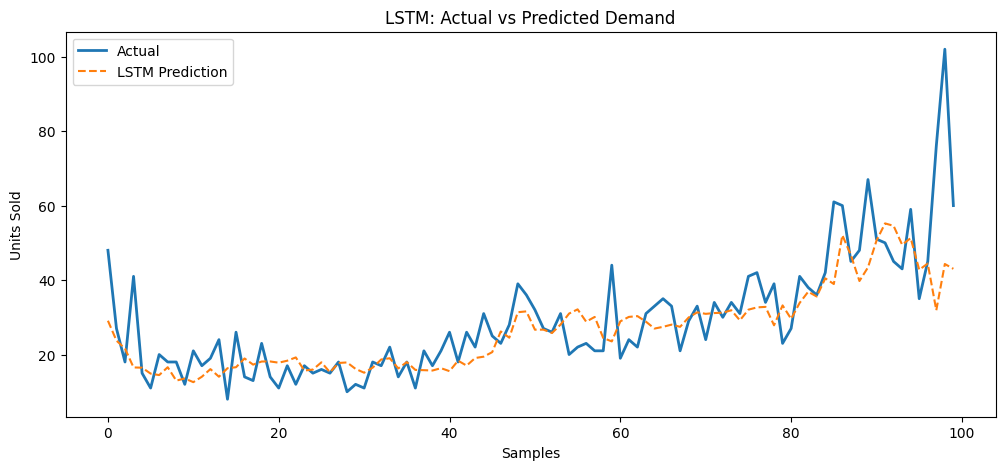

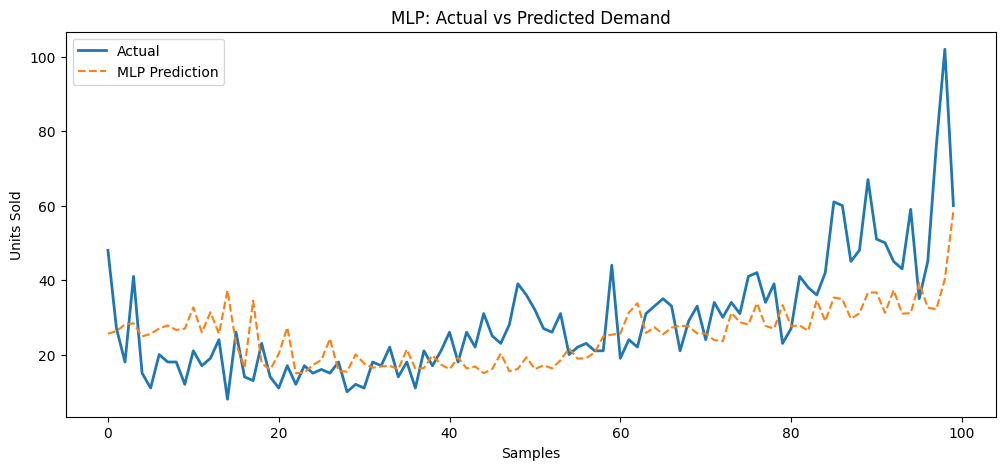

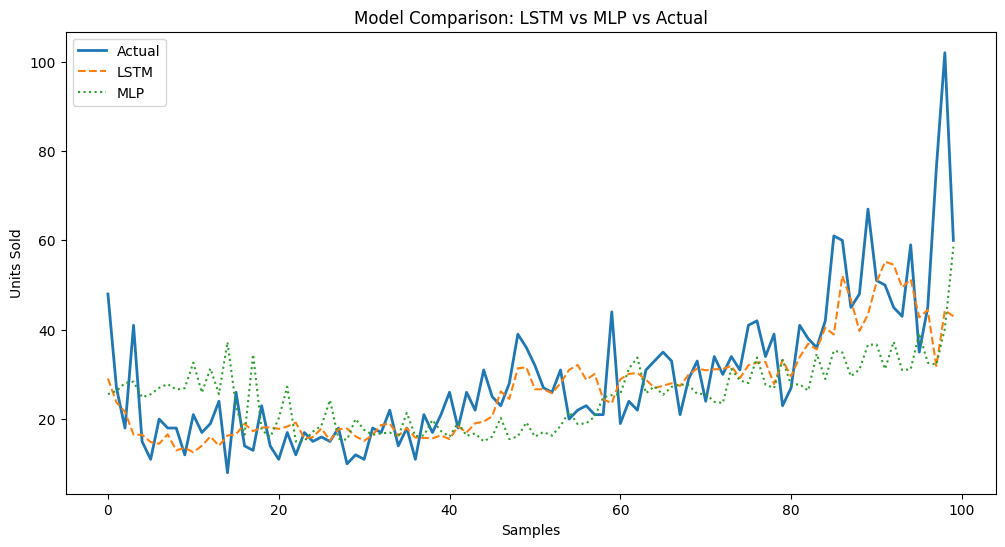

In [15]:
from model import model as lstm_model, mlp_model
from model import lstm_test_loader, mlp_test_loader
from model import device, scaler, cols_to_scale

plot_evaluation(
    lstm_model,
    mlp_model,
    lstm_test_loader,
    mlp_test_loader,
    device,
    scaler,
    cols_to_scale
)

In [17]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("runs/NeuralStock")

In [18]:
writer.add_scalar("Train/Loss", loss.item(), epoch)

In [19]:
writer.add_scalar("Train/Epoch_Loss", avg_loss, epoch)

In [20]:
writer.add_scalar("Test/Loss", avg_test_loss, epoch)

In [21]:
writer.close()